In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
prices_d1 = pd.read_csv("data/prices_round_2_day_1.csv", sep=";")
prices_d0 = pd.read_csv("data/prices_round_2_day_0.csv", sep=";")
prices_d_1 = pd.read_csv("data/prices_round_2_day_-1.csv", sep=";")


def fill_mid_price_by_product(df):
    df = df.copy()
    df = df.sort_values(["product", "timestamp"]).reset_index(drop=True)
    df["mid_price"] = df.groupby("product")["mid_price"].transform(
        lambda s: s.replace(0, np.nan).ffill()
    )
    return df


prices_d1 = fill_mid_price_by_product(prices_d1)
prices_d0 = fill_mid_price_by_product(prices_d0)
prices_d_1 = fill_mid_price_by_product(prices_d_1)

In [18]:
trades_d1 = pd.read_csv("data/trades_round_2_day_1.csv", sep=";")
trades_d0 = pd.read_csv("data/trades_round_2_day_0.csv", sep=";")
trades_d_1 = pd.read_csv("data/trades_round_2_day_-1.csv", sep=";")

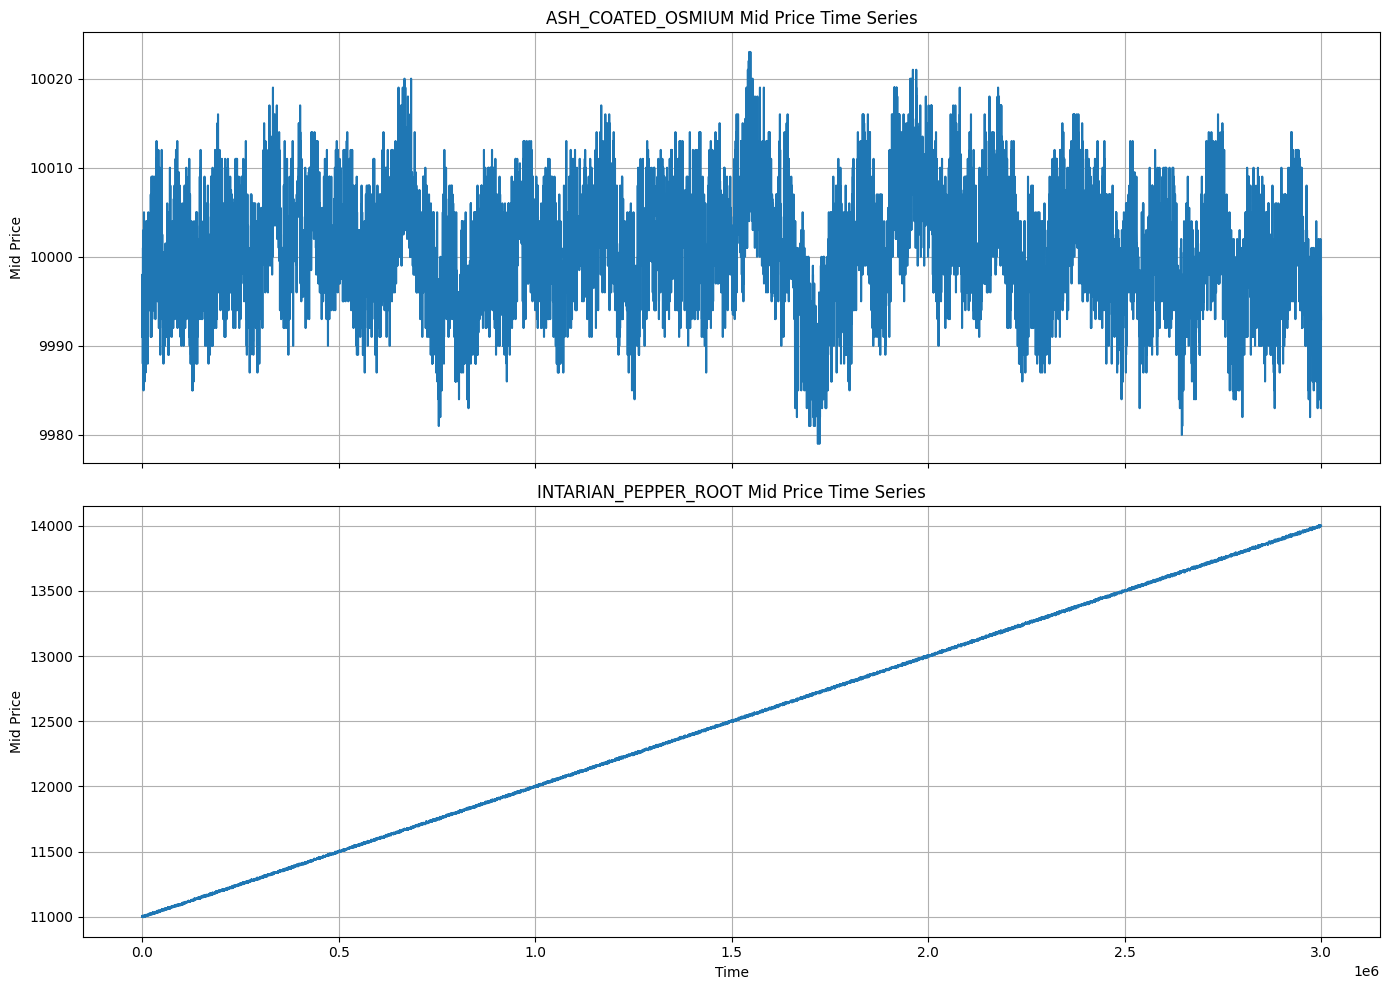

In [19]:
all_prices = pd.concat([prices_d_1, prices_d0, prices_d1], ignore_index=True)
all_prices = all_prices.sort_values(["day", "timestamp"]).reset_index(
    drop=True
)

day_order = {-1: 0, 0: 1, 1: 2}
max_ts = all_prices["timestamp"].max() + 1
all_prices["time_index"] = (
    all_prices["day"].map(day_order) * max_ts + all_prices["timestamp"]
)

products = all_prices["product"].unique()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, product in zip(axes, products):
    df_product = all_prices[all_prices["product"] == product]
    ax.plot(df_product["time_index"], df_product["mid_price"])
    ax.set_title(f"{product} Mid Price Time Series")
    ax.set_ylabel("Mid Price")
    ax.grid(True)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

In [23]:
all_prices[all_prices["product"] == "ASH_COATED_OSMIUM"][
    "mid_price"
].describe()

count    30000.000000
mean     10000.879933
std          5.104634
min       9979.000000
25%       9998.000000
50%      10001.000000
75%      10004.000000
max      10023.000000
Name: mid_price, dtype: float64

In [24]:
all_prices[all_prices["product"] == "INTARIAN_PEPPER_ROOT"][
    "mid_price"
].describe()

count    30000.000000
mean     12499.922783
std        866.031483
min      10998.000000
25%      11750.000000
50%      12500.250000
75%      13250.500000
max      14003.000000
Name: mid_price, dtype: float64

In [26]:
import pandas as pd

trades_d1 = pd.read_csv("data/trades_round_2_day_1.csv", sep=";")
trades_d0 = pd.read_csv("data/trades_round_2_day_0.csv", sep=";")
trades_d_1 = pd.read_csv("data/trades_round_2_day_-1.csv", sep=";")

trades_d1["day"] = 1
trades_d0["day"] = 0
trades_d_1["day"] = -1

all_trades = pd.concat([trades_d_1, trades_d0, trades_d1], ignore_index=True)
all_trades = all_trades.sort_values(["day", "timestamp"]).reset_index(
    drop=True
)

summary = all_trades.groupby("symbol").agg(
    n_trades=("quantity", "count"),
    total_volume=("quantity", "sum"),
    avg_trade_size=("quantity", "mean"),
    max_trade_size=("quantity", "max"),
    active_timestamps=("timestamp", "nunique"),
)

summary

,n_trades,total_volume,avg_trade_size,max_trade_size,active_timestamps
symbol,,,,,
ASH_COATED_OSMIUM,1395,7127,5.108961,10,818
INTARIAN_PEPPER_ROOT,996,5033,5.053213,8,540


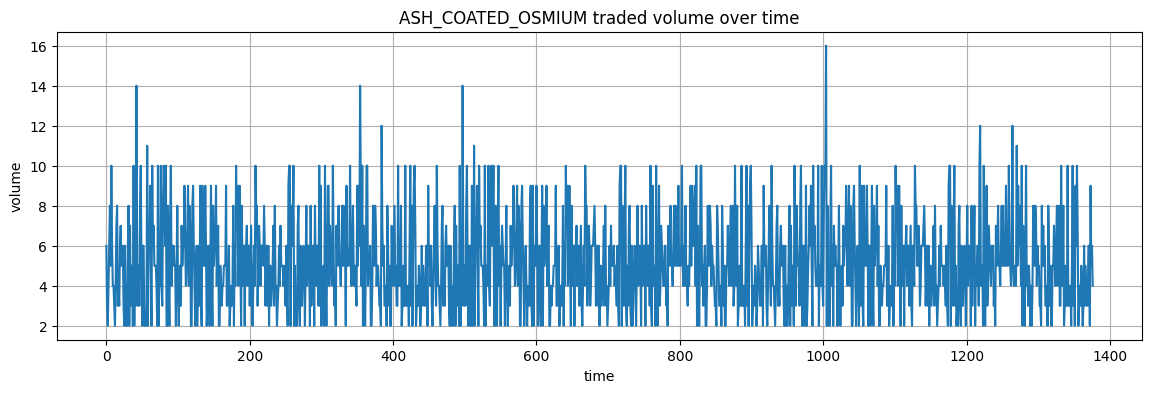

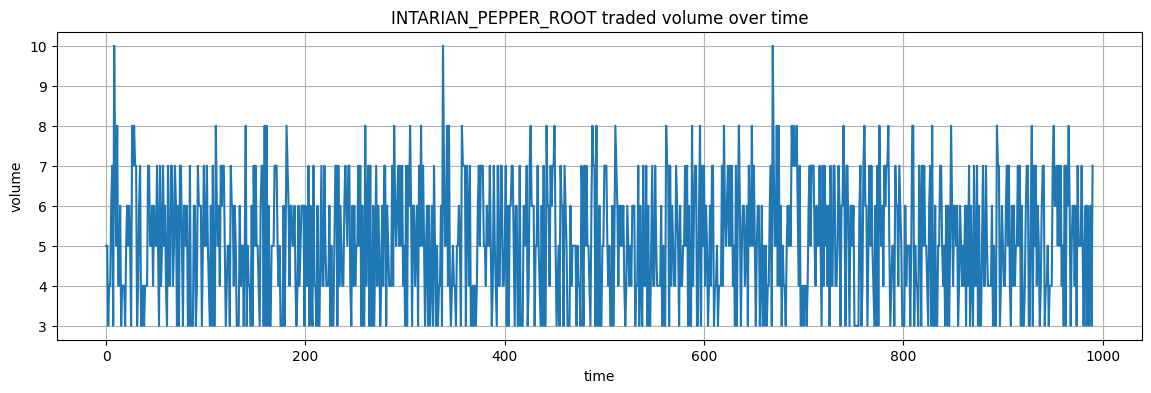

In [27]:
vol_ts = (
    all_trades.groupby(["symbol", "day", "timestamp"])["quantity"]
    .sum()
    .reset_index()
)

for product in vol_ts["symbol"].unique():
    df = vol_ts[vol_ts["symbol"] == product]

    plt.figure(figsize=(14, 4))
    plt.plot(range(len(df)), df["quantity"])
    plt.title(f"{product} traded volume over time")
    plt.xlabel("time")
    plt.ylabel("volume")
    plt.grid(True)
    plt.show()

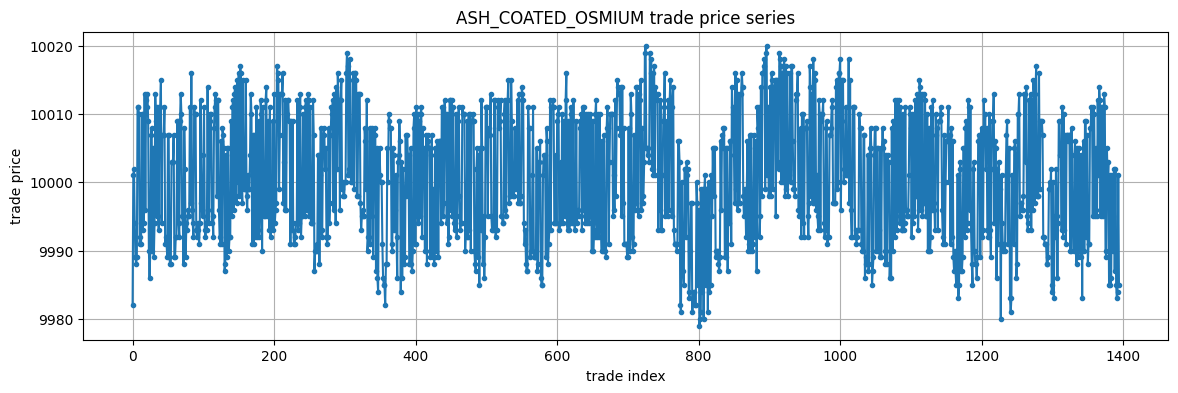

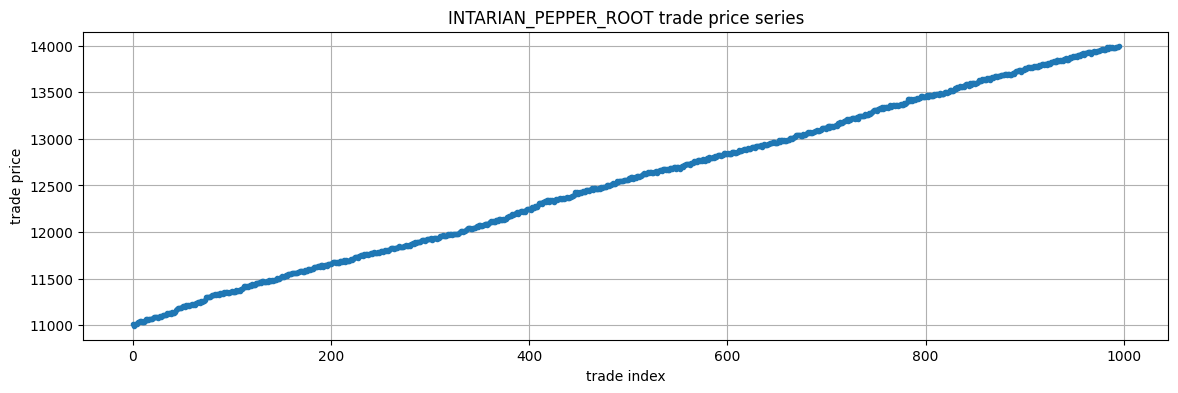

In [28]:
for product in all_trades["symbol"].unique():
    df = all_trades[all_trades["symbol"] == product]

    plt.figure(figsize=(14, 4))
    plt.plot(range(len(df)), df["price"], marker=".", linestyle="-")
    plt.title(f"{product} trade price series")
    plt.xlabel("trade index")
    plt.ylabel("trade price")
    plt.grid(True)
    plt.show()